In [17]:
%pip install folium mapclassify

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl.metadata (2.8 kB)
  Using cached charset_normalizer-3.4.7-cp313-cp313-win_amd64.whl.metadata (41 kB)
   ---------------------------------------- 0.0/882.2 kB ? eta -:--:--
   --------------------------------------- 882.2/882.2 kB 13.5 MB/s eta 0:00:00
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached charset_normalizer-3.4.7-cp313-cp313-win_amd64.whl (158 kB)
Using cached markupsafe-3.0.3-cp313-cp313-win_amd64.whl (15 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
%pip install scikit-learn geopandas pandas numpy pyogrio

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
%pip install seaborn matplotlib statsmodels

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.5 MB 12.2 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.5 MB 16.1 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 16.9 MB/s eta 0:00:00
Using cac


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering, KMeans

# 1. Cargar los datos exportados desde R
gdf = gpd.read_file("glasgow_data.geojson")

# 2. Definir el target y las covariables basándonos en tu código de R
# 'log_price' será nuestro target [cite: 134]
target_col = 'log_price'
# Seleccionamos covariables (ajusta según las columnas disponibles en pricedata)
covariate_cols = ['crime', 'rooms', 'sales', 'drive'] # Ejemplo de columnas comunes



In [3]:
# Creamos el logaritmo del tiempo de conducción (driveshop)
# Usamos log1p por seguridad ante posibles valores de 0
gdf['log_crime'] = np.log1p(gdf['crime'])
gdf['log_driveshop'] = np.log1p(gdf['driveshop'])

# Definimos nuestras covariables finales (mezclando numéricas y logarítmicas)
covariate_cols_final = ['log_crime', 'rooms', 'sales', 'log_driveshop']
target = 'log_price'

In [4]:
print(gdf.columns)

Index(['IZ', 'name', 'easting', 'northing', 'price', 'crime', 'rooms', 'sales',
       'driveshop', 'type', 'log_price', 'geometry', 'log_crime',
       'log_driveshop'],
      dtype='str')


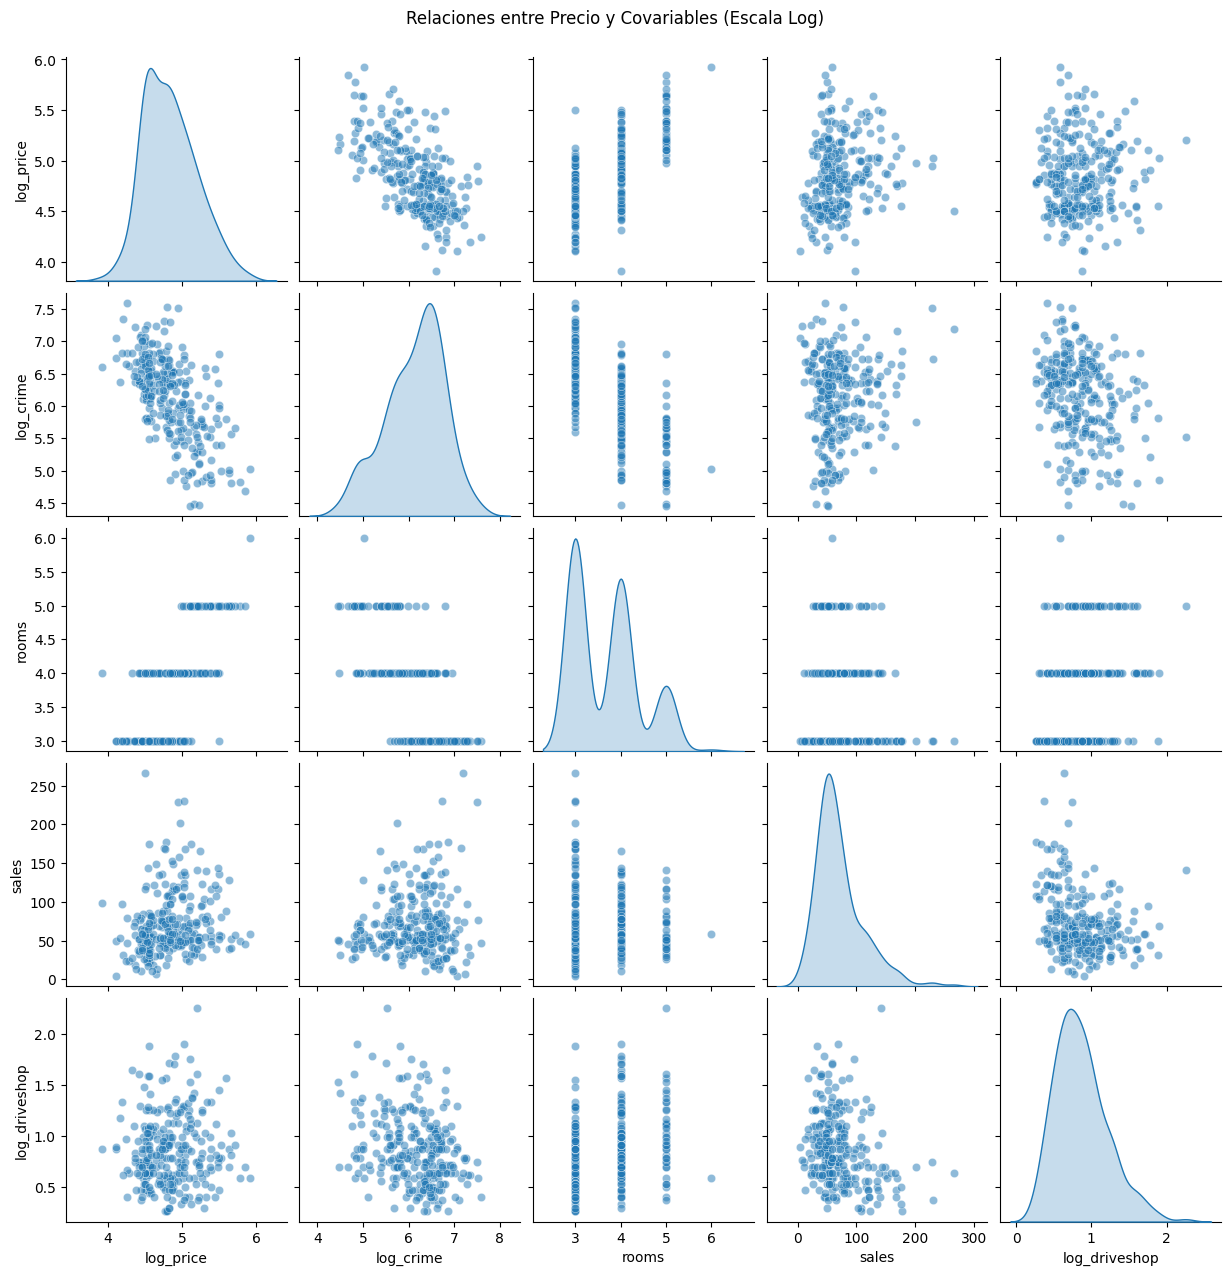

In [5]:
#Visualización en un mapa
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos las columnas para el gráfico
cols_to_plot = [target] + covariate_cols_final

# Generamos la matriz de dispersión
sns.pairplot(gdf[cols_to_plot], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle("Relaciones entre Precio y Covariables (Escala Log)", y=1.02)
plt.show()

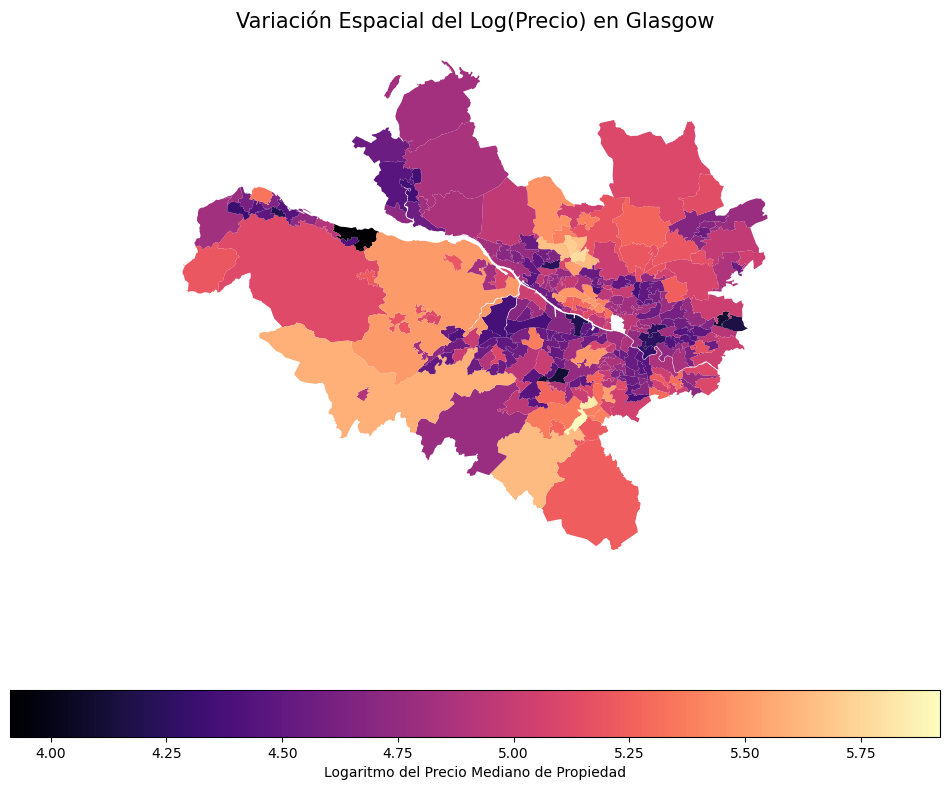

In [6]:
import matplotlib.pyplot as plt

# Configuramos la figura
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Graficamos el GeoDataFrame
# Usamos 'viridis' o 'magma' que son escalas de color perceptualmente uniformes
gdf.plot(column='log_price', 
         cmap='magma', 
         legend=True, 
         legend_kwds={'label': "Logaritmo del Precio Mediano de Propiedad",
                      'orientation': "horizontal"},
         ax=ax)

# Añadimos detalles estéticos
ax.set_title("Variación Espacial del Log(Precio) en Glasgow", fontsize=15)
ax.set_axis_off() # Quitamos los ejes para que parezca un mapa limpio

plt.show()

In [7]:
# Crear el mapa interactivo
# Usamos 'log_price' para el color y mostramos datos útiles en el tooltip
mapa_glasgow = gdf.explore(
    column='log_price',      # Variable que define el color
    cmap='magma',            # Escala de colores (puedes usar 'viridis', 'plasma', etc.)
    tooltip=['name', 'price', 'log_price'],  # Datos que se ven al pasar el ratón
    popup=True,              # Permite hacer clic para ver toda la fila de datos
    legend=True,             # Muestra la barra de escala
    tiles="CartoDB positron" # Fondo de mapa claro y profesional
)

# Mostrar el mapa
mapa_glasgow

In [8]:
""""
The first stage: dividing samples into blocks
we adopt the idea of BLK-CV to divide sample data into blocks.
However, for generating blocks, we use agglomerative hierarchical
clustering (AHC) (Arabie et al., 1996) instead of using square blocks
to avoid its problems as unbalanced amount sample and sample close
to block boundary.
"""

import numpy as np
from sklearn.cluster import AgglomerativeClustering

# Extraemos las coordenadas como nuestra matriz de características para el clustering
# Usamos easting y northing porque están en metros, lo que facilita definir el umbral
# Generar coordenadas a partir de los polígonos
centroids = gdf.geometry.centroid
coords = np.column_stack((centroids.x, centroids.y))



In [17]:
from sklearn.cluster import AgglomerativeClustering

# Asumiendo que 'coords' son tus coordenadas proyectadas de Glasgow (ej. UTM en metros)
# Cambiamos obligatoriamente a 'complete' para respetar la teoría del paper
model_ahc = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=1500,  # Máximo 1500 metros de separación interna por bloque
    linkage='complete'        # Garantiza el cumplimiento del umbral del semivariograma
)

# Ajustamos el modelo y asignamos los bloques al GeoDataFrame
gdf['block_id'] = model_ahc.fit_predict(coords)

print(f"Se han creado {gdf['block_id'].nunique()} bloques espaciales.")

Se han creado 147 bloques espaciales.


In [18]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, SpectralClustering
from kmodes.kprototypes import KPrototypes

def algorithm_2_hbgf(df_blocks, k_folds=5, categorical_indices=None):
    """
    Implementación del Algoritmo 2 del paper: Cluster Ensembles (CE) usando HBGF.
    df_blocks: DataFrame ya agrupado por bloques (Salida de la Etapa 1 / Algoritmo 1)
    categorical_indices: Lista de índices de columnas si hay covariables categóricas en pricedata
    """
    n_blocks = len(df_blocks)
    
    # --- PASO 1: Extraer variables por bloque (Ya promediadas en el paso anterior) ---
    coords = df_blocks[['centroid_x', 'centroid_y']].values
    target = df_blocks[['log_price']].values
    
    # Identificar columnas de covariables (excluyendo id, coords y target)
    exclude = ['block_id', 'centroid_x', 'centroid_y', 'log_price']
    covariate_cols = [col for col in df_blocks.columns if col not in exclude]
    covariates = df_blocks[covariate_cols].values

    # --- PASO 3: Ejecutar los 3 clusterings independientes ---
    
    # • clusters(L): K-Means basado en coordenadas
    km_l = KMeans(n_clusters=k_folds, init='k-means++', n_init=10, random_state=42)
    clusters_L = km_l.fit_predict(coords)
    
    # • clusters(C): K-Prototypes o K-Means basado en covariables
    if categorical_indices:
        kp_c = KPrototypes(n_clusters=k_folds, init='Cao', random_state=42)
        clusters_C = kp_c.fit_predict(covariates, categorical=categorical_indices)
    else:
        km_c = KMeans(n_clusters=k_folds, init='k-means++', n_init=10, random_state=42)
        clusters_C = km_c.fit_predict(covariates)
        
    # • clusters(T): K-Means basado en la variable objetivo
    km_t = KMeans(n_clusters=k_folds, init='k-means++', n_init=10, random_state=42)
    clusters_T = km_t.fit_predict(target)

    # --- PASO 4: Función de Consenso HBGF (Hybrid Bipartite Graph Formulation) ---
    
    # Construcción de la matriz de partición (H)
    # Cada fila es un bloque, cada columna representa la pertenencia a un clúster específico de L, C o T.
    # Total de columnas = 3 * k_folds
    H = np.zeros((n_blocks, 3 * k_folds))
    
    for i in range(n_blocks):
        H[i, clusters_L[i]] = 1
        H[i, k_folds + clusters_C[i]] = 1
        H[i, 2 * k_folds + clusters_T[i]] = 1

    # Construir la matriz de adyacencia del grafo bipartito mixto (W)
    # El grafo conecta tanto los bloques con los clústeres como los bloques entre sí indirectamente
    total_nodes = n_blocks + (3 * k_folds)
    W = np.zeros((total_nodes, total_nodes))
    
    # Asignar las conexiones entre bloques y clústeres en la matriz combinada
    W[:n_blocks, n_blocks:] = H
    W[n_blocks:, :n_blocks] = H.T
    
    # Resolver la partición del grafo usando Clustering Espectral (HBGF matemático)
    # Esto busca cortar el grafo minimizando la pérdida de similitud compartida
    sc = SpectralClustering(
        n_clusters=k_folds, 
        affinity='precomputed', 
        assign_labels='kmeans', 
        random_state=42
    )
    
    final_labels = sc.fit_predict(W)
    
    # Extraer solo las etiquetas que corresponden a los bloques originales (primeros n_blocks nodos)
    df_blocks['fold'] = final_labels[:n_blocks]
    
    return df_blocks[['block_id', 'fold']]

In [20]:
print(gdf.columns.tolist())

['IZ', 'name', 'easting', 'northing', 'price', 'crime', 'rooms', 'sales', 'driveshop', 'type', 'log_price', 'geometry', 'log_crime', 'log_driveshop', 'block_id', 'centroid_x', 'centroid_y']


In [21]:
# 1. Definimos la lista con los nombres EXACTOS de las covariables presentes en tu gdf
# Reemplazamos 'drive' por 'driveshop' (o sus versiones transformadas en log)
covariables_list = ['log_crime', 'rooms', 'sales', 'log_driveshop'] 

# 2. Calcular los centroides de las geometrías (esto ya lo tienes bien)
gdf['centroid_x'] = gdf.geometry.centroid.x
gdf['centroid_y'] = gdf.geometry.centroid.y

# 3. Construimos el diccionario de agregación explícito para evitar conflictos de desempaquetado
diccionario_agregacion = {
    'centroid_x': 'mean',
    'centroid_y': 'mean',
    'log_price': 'mean'
}

# Agregamos dinámicamente las covariables elegidas al diccionario
for col in covariables_list:
    diccionario_agregacion[col] = 'mean'

# 4. Paso 1 del Algoritmo 2: Agregación promediada por bloque libre de errores
df_blocks_aggregated = gdf.groupby('block_id').agg(diccionario_agregacion).reset_index()

print(f"¡Código ejecutado con éxito! Se han colapsado los datos en {len(df_blocks_aggregated)} bloques operativos.")

¡Código ejecutado con éxito! Se han colapsado los datos en 147 bloques operativos.


In [22]:
df_folds_map = algorithm_2_hbgf(df_blocks_aggregated, k_folds=5)

In [23]:
# Unimos el mapeo de los folds usando la columna 'block_id'
gdf_final = gdf.merge(df_folds_map, on='block_id', how='left')

# Verificamos cuántas áreas (Data Zones) tiene cada fold
print("Cantidad de áreas asignadas por cada Fold:")
print(gdf_final['fold'].value_counts())

Cantidad de áreas asignadas por cada Fold:
fold
1    93
3    57
0    57
2    48
4    16
Name: count, dtype: int64


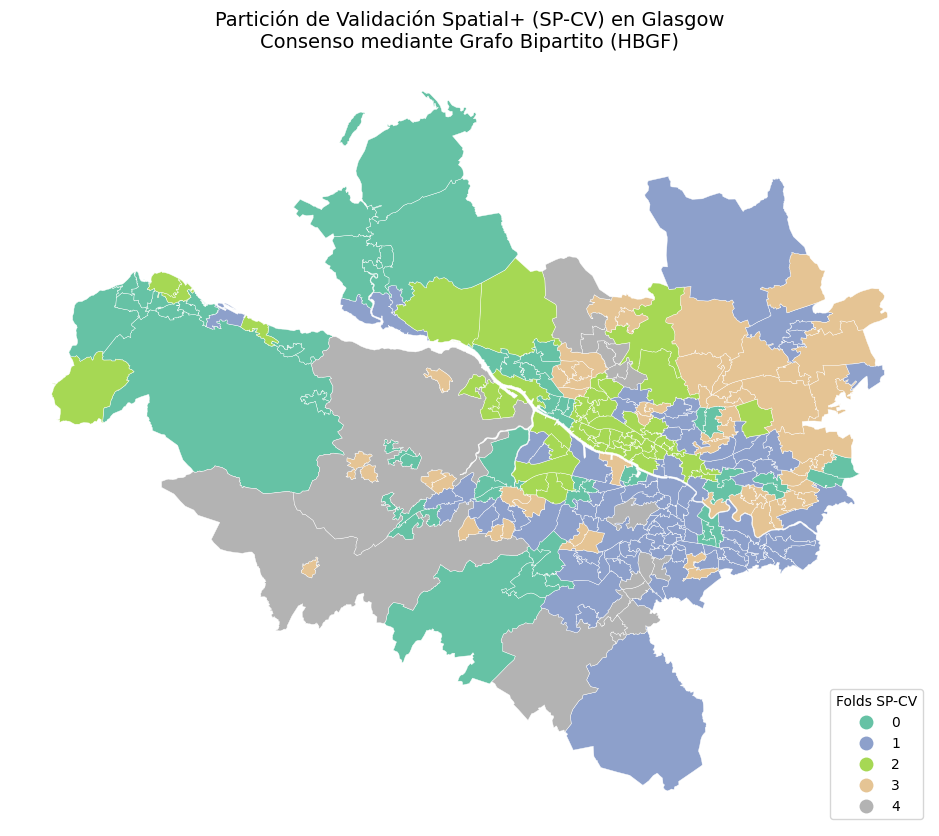

In [24]:
import matplotlib.pyplot as plt

# Configuramos el gráfico
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Graficamos los polígonos de Glasgow coloreados por su número de Fold
gdf_final.plot(
    column='fold', 
    cmap='Set2',          # Paleta de colores cualitativa y limpia
    categorical=True, 
    legend=True, 
    legend_kwds={'title': "Folds SP-CV", 'loc': 'lower right'},
    edgecolor='white',    # Línea blanca fina para separar los distritos
    linewidth=0.3,
    ax=ax
)

plt.title("Partición de Validación Spatial+ (SP-CV) en Glasgow\nConsenso mediante Grafo Bipartito (HBGF)", fontsize=14)
plt.axis('off') # Quitamos los ejes para que luzca como un mapa limpio
plt.show()

In [29]:
!pip install libpysal spreg

  Using cached beautifulsoup4-4.14.3-py3-none-any.whl.metadata (3.8 kB)
  Using cached soupsieve-2.8.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.5 MB 4.4 MB/s eta 0:00:01
   --------------------------------- ------ 2.1/2.5 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 5.9 MB/s eta 0:00:00
Using cached beautifulsoup4-4.14.3-py3-none-any.whl (107 kB)
Using cached soupsieve-2.8.3-py3-none-any.whl (37 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import numpy as np
import pandas as pd
from libpysal.weights import Queen
from spreg import ML_Lag

# 1. Variables a utilizar
target_col = 'log_price'
covariables_list = ['log_crime', 'rooms', 'sales', 'log_driveshop']
todas_las_columnas = [target_col] + covariables_list + ['fold', 'block_id', 'geometry']

# 2. LIMPIEZA CRÍTICA DE NaN E INFINITOS
# Reemplazar infinitos (como los causados por log(0)) por NaN en todo el GeoDataFrame
gdf_limpio = gdf_final[todas_las_columnas].replace([np.inf, -np.inf], np.nan)

# Contar cuántas filas se van a eliminar para el reporte de tu metodología
filas_antes = len(gdf_limpio)
gdf_limpio = gdf_limpio.dropna(subset=[target_col] + covariables_list)
filas_despues = len(gdf_limpio)

if filas_antes != filas_despues:
    print(f"⚠️ Advertencia: Se eliminaron {filas_antes - filas_despues} áreas de Glasgow por contener ceros o valores inválidos en los logaritmos.\n")

# Asegurar que los índices queden limpios y ordenados espacialmente
gdf_limpio = gdf_limpio.reset_index(drop=True)

# 3. Re-estructurar los vectores de datos limpios
y = gdf_limpio[target_col].values.reshape(-1, 1)
X = gdf_limpio[covariables_list].values
folds = gdf_limpio['fold'].values

sar_errors = []
rho_values = []

print("--- Iniciando Validación Cruzada SP-CV para Modelo SAR (Datos Limpios) ---")

# 4. Loop de Validación Cruzada
for fold_idx in range(5):
    train_mask = (folds != fold_idx)
    val_mask = (folds == fold_idx)
    
    # Filtrar conjuntos basándonos en el GeoDataFrame limpio
    gdf_train = gdf_limpio[train_mask]
    
    y_train = y[train_mask]
    X_train = X[train_mask]
    y_val = y[val_mask]
    X_val = X[val_mask]
    
    # Reconstruir la matriz de pesos sin valores nulos
    w_train = Queen.from_dataframe(gdf_train, use_index=False)
    w_train.transform = 'R'  # Estandarizada por filas
    
    # Entrenamiento del Modelo SAR
    model_sar = ML_Lag(y_train, X_train, w=w_train, name_y=target_col, name_x=covariables_list)
    rho_values.append(model_sar.rho)
    
    # Predicción y Evaluación (Efectos directos X*beta)
    beta_coefficients = model_sar.betas[:-1]
    predictions = np.dot(X_val, beta_coefficients[1:]) + beta_coefficients[0]
    
    fold_rmse = np.sqrt(np.mean((y_val - predictions) ** 2))
    sar_errors.append(fold_rmse)
    
    print(f"Fold {fold_idx} aislado -> RMSE: {fold_rmse:.4f} | Rho estimado (ρ): {model_sar.rho:.4f}")

# 5. Reporte Final
print("\n--- Resumen Final del Modelo SAR con SP-CV ---")
print(f"RMSE Promedio Final: {np.mean(sar_errors):.4f}")
print(f"Estabilidad de Rho Promedio: {np.mean(rho_values):.4f}")

⚠️ Advertencia: Se eliminaron 1 áreas de Glasgow por contener ceros o valores inválidos en los logaritmos.

--- Iniciando Validación Cruzada SP-CV para Modelo SAR (Datos Limpios) ---


c:\Users\Magdalena Mendoza\OneDrive - Sento\Documentos\TFM SpatialPlus\env_tfm\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 3 islands with ids: 158, 207, 211.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 158, ' is an island (no neighbors)')
('WARNING: ', 207, ' is an island (no neighbors)')
('WARNING: ', 211, ' is an island (no neighbors)')
ML_Lag
Fold 0 aislado -> RMSE: 0.1973 | Rho estimado (ρ): 0.0302
('WARNING: ', 22, ' is an island (no neighbors)')
('WARNING: ', 40, ' is an island (no neighbors)')


c:\Users\Magdalena Mendoza\OneDrive - Sento\Documentos\TFM SpatialPlus\env_tfm\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 7 disconnected components.
 There are 2 islands with ids: 22, 40.
  W.__init__(self, neighbors, ids=ids, **kw)


ML_Lag
Fold 1 aislado -> RMSE: 0.2764 | Rho estimado (ρ): 0.0324
('WARNING: ', 108, ' is an island (no neighbors)')


c:\Users\Magdalena Mendoza\OneDrive - Sento\Documentos\TFM SpatialPlus\env_tfm\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
 There is 1 island with id: 108.
  W.__init__(self, neighbors, ids=ids, **kw)


ML_Lag
Fold 2 aislado -> RMSE: 0.3859 | Rho estimado (ρ): 0.0335
('WARNING: ', 152, ' is an island (no neighbors)')


c:\Users\Magdalena Mendoza\OneDrive - Sento\Documentos\TFM SpatialPlus\env_tfm\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 4 disconnected components.
 There is 1 island with id: 152.
  W.__init__(self, neighbors, ids=ids, **kw)


ML_Lag
Fold 3 aislado -> RMSE: 0.5585 | Rho estimado (ρ): 0.1199
('WARNING: ', 22, ' is an island (no neighbors)')
('WARNING: ', 186, ' is an island (no neighbors)')
('WARNING: ', 210, ' is an island (no neighbors)')
('WARNING: ', 221, ' is an island (no neighbors)')
ML_Lag
Fold 4 aislado -> RMSE: 0.5504 | Rho estimado (ρ): 0.0309

--- Resumen Final del Modelo SAR con SP-CV ---
RMSE Promedio Final: 0.3937
Estabilidad de Rho Promedio: 0.0494


c:\Users\Magdalena Mendoza\OneDrive - Sento\Documentos\TFM SpatialPlus\env_tfm\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 9 disconnected components.
 There are 4 islands with ids: 22, 186, 210, 221.
  W.__init__(self, neighbors, ids=ids, **kw)
